# 💵🪙💻 AutomaticCashier: An Automatic Object Detection Based Currency Counter 💵🪙💻

- Author:
   [Timothy Do](https://timothydo.me)
  

In [1]:
!pip install -r requirements.txt

## Dependencies

In [1]:
%matplotlib inline
import os
import shutil
import glob
import random
import numpy as np 
import cv2 as cv
import matplotlib.pyplot as plt
import ultralytics
import datasets
from tqdm import tqdm

## Dataset 

In [3]:
dataset_name = "Francesco/currency-v4f8j"
output_dir = "./data/currency-v4f8j"
os.makedirs(output_dir,exist_ok=True)

In [4]:
# Load the specific currency dataset
print("Loading Currency Dataset...")
dataset = datasets.load_dataset(dataset_name)
print("Dataset Loaded!")
# View the structure of the downloaded dataset
print(dataset)

Loading Currency Dataset...


Dataset Loaded!
DatasetDict({
    train: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 576
    })
    validation: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 82
    })
    test: Dataset({
        features: ['image_id', 'image', 'width', 'height', 'objects'],
        num_rows: 155
    })
})


In [5]:
# Extract actual class names directly from the dataset features
class_names = dataset['train'].features['objects'].feature['category'].names
yaml_classes = {idx: name for idx, name in enumerate(class_names)}

# Process splits (train, validation, test)
for split in dataset.keys():
    print(f"Processing split: {split}...")
    
    # Map 'validation' to 'val' to match standard Ultralytics structure
    ultralytics_split = "val" if split == "validation" else split
    
    images_path = os.path.join(output_dir, ultralytics_split, "images")
    labels_path = os.path.join(output_dir, ultralytics_split, "labels")
    
    os.makedirs(images_path, exist_ok=True)
    os.makedirs(labels_path, exist_ok=True)
    
    for idx, item in tqdm(enumerate(dataset[split])):
        # Save image and calculate actual sizes for normalization
        img = item['image']
        img_w, img_h = img.size
        img_filename = f"img_{idx}.jpg"
        img.save(os.path.join(images_path, img_filename))
        
        # Save Ultralytics/YOLO format labels (class x_center y_center width height)
        label_filename = f"img_{idx}.txt"
        with open(os.path.join(labels_path, label_filename), "w") as f:
            if 'objects' in item and item['objects']:
                bboxes = item['objects']['bbox']          # Format: [x_min, y_min, width, height]
                categories = item['objects']['category']  # List of integer class IDs
                
                for obj_idx in range(len(bboxes)):
                    cls = categories[obj_idx]
                    x_min, y_min, w, h = bboxes[obj_idx]
                    
                    # Compute normalized center coordinates relative to raw image width and height
                    x_center = (x_min + (w / 2)) / img_w
                    y_center = (y_min + (h / 2)) / img_h
                    norm_w = w / img_w
                    norm_h = h / img_h
                    
                    # Constrain ranges between 0.0 and 1.0 to prevent layout parsing errors
                    x_center = max(0.0, min(1.0, x_center))
                    y_center = max(0.0, min(1.0, y_center))
                    norm_w = max(0.0, min(1.0, norm_w))
                    norm_h = max(0.0, min(1.0, norm_h))
                    
                    # Write formatted line item
                    f.write(f"{cls} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}\n")

# 4. Create the dataset config file for Ultralytics with authentic class names
yaml_content = f"""
path: {os.path.abspath(output_dir)}
train: train/images
val: val/images
test: test/images

names:
"""
for idx, name in yaml_classes.items():
    yaml_content += f"  {idx}: {name}\n"

yaml_path = os.path.join(output_dir, "data.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(f"Dataset successfully exported to {output_dir}. Ready for Ultralytics!")

Processing split: train...


576it [00:01, 325.33it/s]


Processing split: validation...


82it [00:00, 336.05it/s]


Processing split: test...


155it [00:00, 336.23it/s]

Dataset successfully exported to ./data/currency-v4f8j. Ready for Ultralytics!


# Model 

In [6]:
# 1. Configuration paths
project_dir = "."
full_exp_path = "./runs/detect/train"

os.makedirs("./model", exist_ok=True)

# 2. Delete old runs folder before starting to prevent overlapping files
if os.path.exists(full_exp_path):
    print(f"Cleaning workspace: Deleting old experiment folder at {full_exp_path}...")
    shutil.rmtree(full_exp_path)

# 3. Initialize the YOLO26 model
model = ultralytics.YOLO("yolo26n.pt")

# 4. Train the model
results = model.train(
    data="./data/currency-v4f8j/data.yaml",
    epochs=250,
    imgsz=640,
    batch=128,
    project=project_dir,       # Forces saving directly into your local runs directory
)

# 5. Programmatically isolate and move the final trained model weights
best_weights_src = os.path.join(full_exp_path, "weights/best.pt")
final_destination = "./model/AutomaticCashier_best_YOLO26.pt"

if os.path.exists(best_weights_src):
    shutil.copy(best_weights_src, final_destination)
    print(f"\n Success! Final production weights exported to: {final_destination}")
else:
    print(f"\n Error: Could not find trained weights at {best_weights_src}")
    print(f"\n Error: Could not find trained weights at {best_weights_src}")

Cleaning workspace: Deleting old experiment folder at ./runs/detect/train...
Ultralytics 8.4.56  Python-3.11.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data/currency-v4f8j/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=250, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nb

In [7]:
# 1. Configuration paths
project_dir = "."
full_exp_path = "./runs/detect/val"

# 2. Reset previous validation runs to keep workspace clean
if os.path.exists(full_exp_path):
    print(f"Cleaning workspace: Deleting old validation folder at {full_exp_path}...")
    shutil.rmtree(full_exp_path)
    
# 3. Load your final trained production model weights
model_path = "./model/AutomaticCashier_best_YOLO26.pt"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Trained model weights not found at {model_path}. Did you run training first?")
    
print(f"Loading trained model from {model_path}...")
model = ultralytics.YOLO(model_path)

# 4. Run validation on the dataset split
print("Starting validation process...")
metrics = model.val(
    data="./data/currency-v4f8j/data.yaml",  # Path to your config file
    split="val",                             # Explicitly targets the validation split
    imgsz=640,                               # Match training image size
    batch=128,                                
)

Cleaning workspace: Deleting old validation folder at ./runs/detect/val...
Loading trained model from ./model/AutomaticCashier_best_YOLO26.pt...
Starting validation process...
Ultralytics 8.4.56  Python-3.11.7 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 962.3191.0 MB/s, size: 65.0 KB)
val: Scanning C:\Users\Timothy Do\Documents\GitHub\AutomaticCashier\data\currency-v4f8j\val\labels.cache... 82 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.3s/it 3.3s
                   all         82        652      0.929      0.904      0.968      0.913
                  Dime         15        148      0.978      0.884      0.979      0.812
                Nickel         22        165       0.97      0.848      0.978      0.853

Cleaning workspace: Deleting old test inference folder at ./runs/detect/predict...
Loading model and predicting on test images from ./data/currency-v4f8j/test/images...

image 1/155 C:\Users\Timothy Do\Documents\GitHub\AutomaticCashier\data\currency-v4f8j\test\images\img_0.jpg: 640x640 1 twenty, 11.9ms
image 2/155 C:\Users\Timothy Do\Documents\GitHub\AutomaticCashier\data\currency-v4f8j\test\images\img_1.jpg: 640x640 1 fifty, 11.9ms
image 3/155 C:\Users\Timothy Do\Documents\GitHub\AutomaticCashier\data\currency-v4f8j\test\images\img_10.jpg: 640x640 19 Dimes, 4 Nickels, 11.7ms
image 4/155 C:\Users\Timothy Do\Documents\GitHub\AutomaticCashier\data\currency-v4f8j\test\images\img_100.jpg: 640x640 2 Dimes, 7 Nickels, 10 Pennys, 11.8ms
image 5/155 C:\Users\Timothy Do\Documents\GitHub\AutomaticCashier\data\currency-v4f8j\test\images\img_101.jpg: 640x640 1 Penny, 11.6ms
image 6/155 C:\Users\Timothy Do\Documents\GitHub\AutomaticCashier\data\currency-v4f8j\test\images\img_102.jpg: 640x640 1 ten,

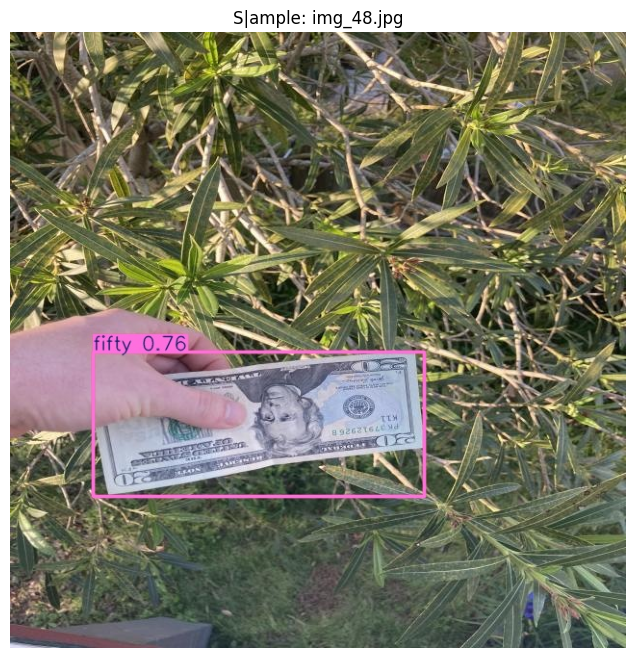

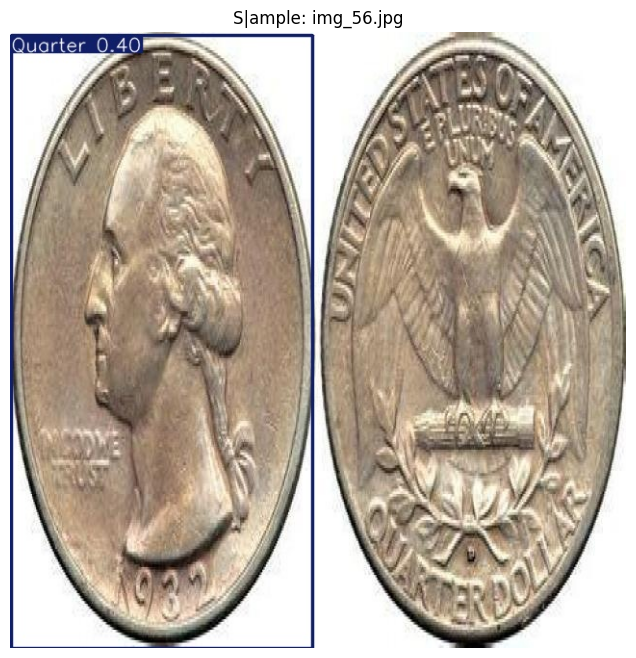

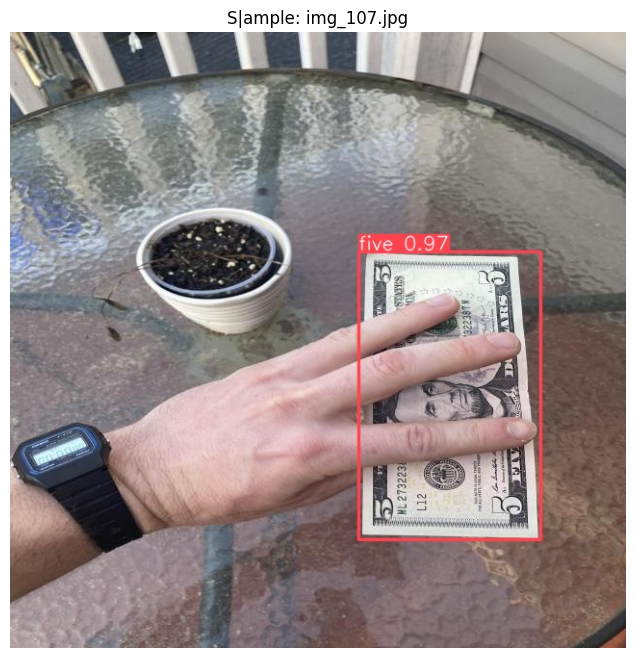

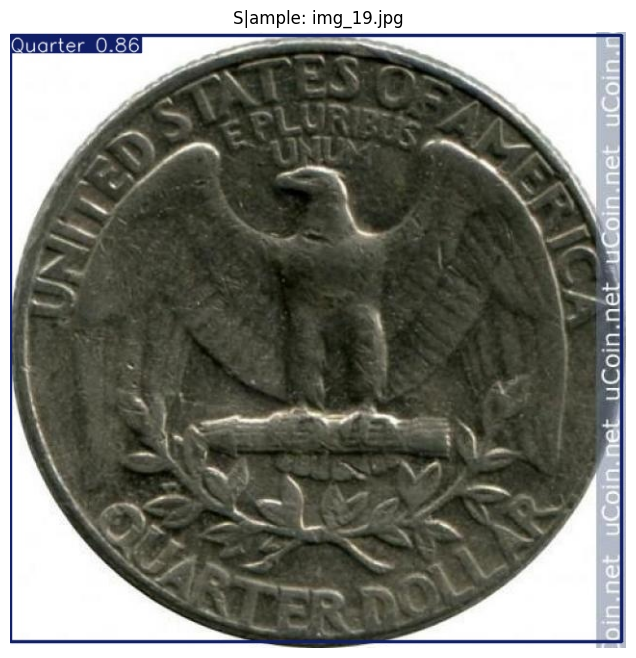

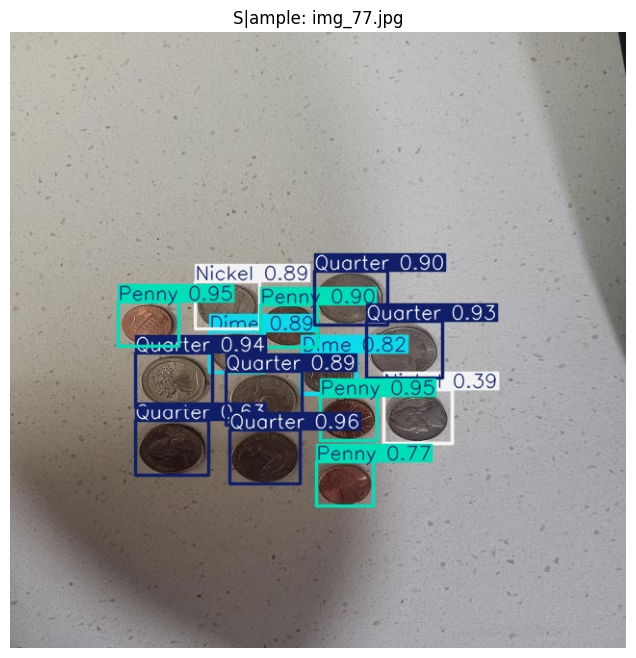

In [8]:
# 1. Configuration paths
project_dir = "."
test_images_dir = "./data/currency-v4f8j/test/images"
model_path = "./model/AutomaticCashier_best_YOLO26.pt"
full_exp_path = "./runs/detect/predict"

# 2. Reset previous inference runs to keep workspace clean
if os.path.exists(full_exp_path):
    print(f"Cleaning workspace: Deleting old test inference folder at {full_exp_path}...")
    shutil.rmtree(full_exp_path)

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Trained model weights not found at {model_path}.")

# 3. Load the model and run inference on the entire test folder
print(f"Loading model and predicting on test images from {test_images_dir}...")
model = ultralytics.YOLO(model_path)

results = model.predict(
    source=test_images_dir,
    imgsz=640,
    conf=0.25,              # Only show detections with >25% confidence
    device=0,               # Use RTX 3090
    save=True,              # Saves annotated images to disk
)

print(f"\nAll annotated images successfully saved to: {full_exp_path}")

# 4. Visualize 3 random annotated test results inline within the Notebook
print("\nVisualizing random prediction samples:")
saved_images = glob.glob(os.path.join(full_exp_path, "*.jpg"))

if saved_images:
    # Select up to 3 random images to display
    random.seed(0)
    samples = random.sample(saved_images, min(5, len(saved_images)))
    
    for img_path in samples:
        img = cv.cvtColor(cv.imread(img_path),cv.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.title(f"S|ample: {os.path.basename(img_path)}")
        plt.axis('off')
        plt.show()

In [2]:
# 1. Path to your production weights
model_path = "./model/AutomaticCashier_best_YOLO26.pt"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Trained model weights not found at {model_path}.")

print(f"Loading trained PyTorch model from {model_path}...")
model = ultralytics.YOLO(model_path)

# 2. Export the model to ONNX with Opset 17
print("Exporting model to ONNX format (Opset 17)...")
onnx_path = model.export(
    format="onnx",
    opset=17,         
    imgsz=640,        
    dynamic=False,     
    simplify=False,
    name="model/AutomaticCashier_best_YOLO26.onnx"
)

print(f"\nSuccess! ONNX model exported and saved to: {onnx_path}")

Loading trained PyTorch model from ./model/AutomaticCashier_best_YOLO26.pt...
Exporting model to ONNX format (Opset 17)...
Ultralytics 8.4.56  Python-3.11.7 torch-2.6.0+cu124 CPU (11th Gen Intel Core i7-11700K @ 3.60GHz)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'model\AutomaticCashier_best_YOLO26.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.2 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: export success  0.8s, saved as 'model\AutomaticCashier_best_YOLO26.onnx' (9.3 MB)

Export complete (1.1s)
Results saved to C:\Users\Timothy Do\Documents\GitHub\AutomaticCashier\model\AutomaticCashier_best_YOLO26.onnx
Predict:         yolo predict task=detect model=model\AutomaticCashier_best_YOLO26.onnx imgsz=640 
Validate:        yolo val task=detect model=model\AutomaticCashier_best_YOLO26.onnx imgsz=640 data=data\currency-v4f8j\data.yaml  
Visualize:       https://netron.app

Success! O

C:\Users\Timothy Do\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\onnx\symbolic_opset9.py:5383: UserWarning: Exporting aten::index operator of advanced indexing in opset 17 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(
